<a href="https://colab.research.google.com/github/SihamDaanouni/InstantMesh/blob/diffusion_swap/Multiple%20diffusion%20models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparation & Installation

In [7]:
## CLONE DU FORK INSTANTMESH

# -*- coding: utf-8 -*-

import os
import shutil

%cd /content

# Nettoyage en cas de relance
if os.path.exists('/content/InstantMesh'):
    shutil.rmtree('/content/InstantMesh')

# Clonage de VOTRE fork sur la branche diffusion_swap
!GIT_LFS_SKIP_SMUDGE=1 git clone -b diffusion_swap https://github.com/SihamDaanouni/InstantMesh.git
%cd /content/InstantMesh

/content
Cloning into 'InstantMesh'...
remote: Enumerating objects: 357, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 357 (delta 138), reused 106 (delta 106), pack-reused 168 (from 2)
Receiving objects: 100% (357/357), 39.33 MiB | 19.51 MiB/s, done.
Resolving deltas: 100% (146/146), done.
/content/InstantMesh


In [2]:
## INSTALATION DES DDEPENDANCES

# Clonage de SyncDreamer
%cd /content
if os.path.exists('/content/SyncDreamer'):
    shutil.rmtree('/content/SyncDreamer')
!GIT_LFS_SKIP_SMUDGE=1 git clone https://github.com/liuyuan-pal/SyncDreamer
!pip install -r "/content/SyncDreamer/requirements.txt"

# 1. Fix numpy AVANT tout
!pip install -q "numpy<2.0.0"

# 2. GPU et utilitaires 3D
!pip install -q onnxruntime-gpu ninja
!pip install -q PyMCubes trimesh rembg xatlas plyfile imageio[ffmpeg] jax==0.4.19 jaxlib==0.4.19

# 3. Machine Learning
!pip install -q pytorch-lightning==2.1.2 gradio==3.50.2 einops omegaconf torchmetrics webdataset accelerate tensorboard

# 4. HuggingFace
!pip install -q "huggingface-hub<1.0" "transformers>=4.41.0" "diffusers>=0.27.0"

# 5. Variables CUDA
os.environ['CUDA_HOME'] = '/usr/local/cuda'
os.environ['PATH'] += ':/usr/local/cuda/bin'
os.environ['LD_LIBRARY_PATH'] += ':/usr/local/cuda/lib64'

# 6. nvdiffrast
%cd /content
if os.path.exists('/content/nvdiffrast'):
    shutil.rmtree('/content/nvdiffrast')
!git clone https://github.com/NVlabs/nvdiffrast.git
%cd /content/nvdiffrast
!pip install -q --no-build-isolation .

# more stuff
!pip install -q "cupy-cuda12x<14.0.0"
!pip uninstall -y flax
!pip install -q --upgrade transformers==4.41.0 diffusers==0.27.0 jax==0.4.23 jaxlib==0.4.23
!pip install -q huggingface_hub==0.25.2
!pip install -q peft==0.10.0

%cd /content/InstantMesh
print("\n=== INSTALLATION TERMINÉE ===")
print("Branche active :", end=" ")
!git branch --show-current

/content
Cloning into 'SyncDreamer'...
remote: Enumerating objects: 405, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 405 (delta 48), reused 32 (delta 31), pack-reused 341 (from 1)
Receiving objects: 100% (405/405), 83.54 MiB | 16.05 MiB/s, done.
Resolving deltas: 100% (112/112), done.
  Cloning https://github.com/NVlabs/tiny-cuda-nn/ to /tmp/pip-req-build-vjnl4a3c
  Running command git clone --filter=blob:none --quiet https://github.com/NVlabs/tiny-cuda-nn/ /tmp/pip-req-build-vjnl4a3c
  Resolved https://github.com/NVlabs/tiny-cuda-nn/ to commit 749dd70c5afc5a9dadb85e5652ed65d55e0ba187
  Running command git submodule update --init --recursive -q
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-qzw2smoq
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-qzw2smoq
  Resolved https://github.com/openai/CLIP

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires flax>=0.2.0, which is not installed.
rembg 2.0.75 requires numpy<3.0.0,>=2.3.0, but you have numpy 1.26.4 which is incompatible.
rembg 2.0.75 requires pillow<13.0.0,>=12.1.0, but you have pillow 10.0.0 which is incompatible.
rembg 2.0.75 requires scikit-image<0.27.0,>=0.26.0, but you have scikit-image 0.24.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0.4.23 which is incompatible.
optax 0.2.8 requires jaxlib>=0.5.3, but you have jaxlib 0.4.23 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requir

In [1]:
## TELECHARGEMENT DES CHECKPOINTS POUR SYNCDREAMER
!pip install -q gdown
import gdown
import urllib.request
import os

output_dir = "/content/SyncDreamer/ckpt"
os.makedirs(output_dir, exist_ok=True)

# SYNC DREAM PRETRAIN
SYNCDREAM_URL = "https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam"
output = os.path.join(output_dir, "syncdreamer-pretrain.ckpt")
# download
gdown.download(SYNCDREAM_URL, output, quiet=False)

# VIT L 14
VITL14_URL = "https://openaipublic.azureedge.net/clip/models/b8cca3fd41ae0c99ba7e8951adf17d267cdb84cd88be6f7c2e0eca1737a03836/ViT-L-14.pt"
output = os.path.join(output_dir, "ViT-L-14.pt")
# download
urllib.request.urlretrieve(VITL14_URL, output)


Downloading...
From (original): https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam
From (redirected): https://drive.google.com/uc?id=1ypyD5WXxAnsWjnHgAfOAGolV0Zd9kpam&confirm=t&uuid=c55942ee-91d2-4f93-80ff-a37b8cf32961
To: /content/SyncDreamer/ckpt/syncdreamer-pretrain.ckpt
100%|██████████| 5.57G/5.57G [01:01<00:00, 90.2MB/s]


('/content/SyncDreamer/ckpt/ViT-L-14.pt',
 <http.client.HTTPMessage at 0x7b61d3b7fdd0>)

# Google Scanned Objects Dataset

In [ ]:
# 7. Google Scanned Objects Dataset
%cd /content

from pathlib import Path
from zipfile import ZipFile
import os

GOOGLE_FOLDER = Path("/content/Google_data/")

if not GOOGLE_FOLDER.exists():
    GOOGLE_FOLDER.mkdir(exist_ok=True)
    os.chdir(GOOGLE_FOLDER)
    os.system("curl -O https://app.gazebosim.org/assets/scripts/download_collection.py")
    os.system("python3 download_collection.py -o \"GoogleResearch\" -c \"Scanned Objects by Google Research\"")

OBJS = {
    "Weisshai_Great_White_Shark",
    "Vtech_Stack_Sing_Rings_636_Months",
    "Vtech_Roll_Learn_Turtle",
    "Vtech_Cruise_Learn_Car_25_Years",
    "Victor_Reversible_Bookend",
    "VEGETABLE_GARDEN",
    "TriStar_Products_PPC_Power_Pressure_Cooker_XL_in_Black",
    "Toysmith_Windem_Up_Flippin_Animals_Dog",
    "Threshold_Porcelain_Spoon_Rest_White",
    "TABLEWARE_SET_5ww1UFLuCJG",
    "TWIST_SHAPE",
    "TEA_SET",
    "TWISTED_PUZZLE",
    "TABLEWARE_SET_5CHkPjjxVpp",
    "TABLEWARE_SET",
    "Squirrel",
    "Sootheze_Cold_Therapy_Elephant",
    "Shark",
    "Sootheze_Toasty_Orca",
    "Schleich_Lion_Action_Figure",
    "Schleich_S_Bayala_Unicorn_70432",
    "Schleich_Spinosaurus_Action_Figure",
    "Schleich_Therizinosaurus_ln9cruulPqc",
    "Sonny_School_Bus",
    "Schleich_Hereford_Bull",
    "Schleich_Bald_Eagle",
    "Schleich_Allosaurus",
    "Schleich_African_Black_Rhino",
    "STEAK_SET",
    "STACKING_BEAR_V04KKgGBn2A",
    "STACKING_BEAR",
    "SORTING_TRAIN",
    "SORTING_BUS",
    "SHAPE_SORTER",
    "SHAPE_MATCHING_NxacpAY9jDt",
    "SHAPE_MATCHING",
    "SANDWICH_MEAL",
    "Rubbermaid_Large_Drainer",
    "Room_Essentials_Dish_Drainer_Collapsible_White",
    "Razer_Kraken_Pro_headset_Full_size_Black",
    "Remington_TStudio_Hair_Dryer",
    "Razer_Taipan_White_Ambidextrous_Gaming_Mouse",
    "Razer_BlackWidow_Stealth_2014_Keyboard_07VFzIVabgh",
    "Racoon",
    "ProSport_Harness_to_Booster_Seat",
    "PARENT_ROOM_FURNITURE_SET_1_DLKEy8H4mwK",
    "PUNCH_DROP",
    "POUNDING_MUSHROOMS",
    "Ortho_Forward_Facing_QCaor9ImJ2G",
    "Ortho_Forward_Facing_3Q6J2oKJD92",
    "Ortho_Forward_Facing",
    "Ocedar_Snap_On_Dust_Pan_And_Brush_1_ct",
    "OXO_Soft_Works_Can_Opener_SnapLock",
    "Object",
    "JA_Henckels_International_Premio_Cutlery_Block_Set_14Piece",
    "Great_Dinos_Triceratops_Toy",
    "Granimals_20_Wooden_ABC_Blocks_Wagon_g2TinmUGGHI",
    "FARM_ANIMAL",
    "Dino_5",
    "Dino_4",
    "Dino_3",
    "DANCING_ALLIGATOR_zoWBjc0jbTs",
    "Crosley_Alarm_Clock_Vintage_Metal",
    "CASTLE_BLOCKS",
    "Android_Lego",
    "Animal_Planet_Foam_2Headed_Dragon",
    "Transformers_Age_of_Extinction_Mega_1Step_Bumblebee_Figure",
    "Transformers_Age_of_Extinction_Stomp_and_Chomp_Grimlock_Figure",
    "Thomas_Friends_Wooden_Railway_Talking_Thomas_z7yi7UFHJRj",
    "Teenage_Mutant_Ninja_Turtles_Rahzar_Action_Figure",
    "Superman_Battle_of_Smallville",
    "Nintendo_Mario_Action_Figure",
    "Nintendo_Yoshi_Action_Figure",
    "My_Little_Pony_Princess_Celestia",
    "Lenovo_Yoga_2_11",
    "LEGO_Duplo_Build_and_Play_Box_4629",
    "LEGO_Duplo_Creative_Animals_10573",
    "LEGO_5887_Dino_Defense_HQ",
    "BlueBlack_Nintendo_3DSXL",
    "2_of_Jenga_Classic_Game"
}

def get_whitelist():
    return {obj + ".zip" for obj in OBJS}

whitelist = get_whitelist()
for zip_file in GOOGLE_FOLDER.glob("*.zip"):
    if zip_file.name not in whitelist:
        print("Deleting: ", zip_file.name)
        zip_file.unlink()

def get_google_ref(path_to_ref:Path = GOOGLE_FOLDER/"Nintendo_Mario_Action_Figure.zip", random:bool=False):
    image_path = ""
    model_path = ""
    with ZipFile(path_to_ref, mode="r") as z:
        namelist = z.namelist()
        image_paths = [path for path in namelist if path.endswith(".jpg")].sort()
        image_path = rd.choice(image_paths) if random else image_paths[0]
        model_path = [path for path in namelist if path.endswith(".obj")].pop()
    
    return image_path, model_path

# Inference

In [4]:
# =========================================================
# INFÉRENCE — Référence originale (fine-tuned)
# =========================================================
%cd /content/InstantMesh

!python run.py configs/instant-mesh-base.yaml examples/hatsune_miku.png \
    --save_video \
    --diffusion_model zero123plus_finetuned

print("Référence terminée")
print("outputs/instant-mesh-base_zero123plus_finetuned/")

/content/InstantMesh
Seed set to 42
[Diffusion] Modèle choisi : zero123plus_finetuned
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-05-09 14:49:30.559677: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading pipeline components...: 100% 8/8 [00:16<00:00,  2.01s/it]
[Diffusion] Chargement du UNet fine-tuné InstantMesh (fond blanc)...
[Diffusion] UNet fine-tuné chargé ✓
Total input images: 1
[1/1] Imagining hatsune_miku ... (mode: zero123plus_finetuned)
100% 75/75 [00:39<00:00,  1.90it/s]
Loading reconstruc

In [3]:
# =========================================================
# INFÉRENCE — Option A : sans fine-tuning
# =========================================================
%cd /content/InstantMesh

!python run.py configs/instant-mesh-base.yaml examples/hatsune_miku.png \
    --save_video \
    --diffusion_model zero123plus_base

print("Option A : modèle sans fine-tuning terminée")
print("outputs/instant-mesh-base_zero123plus_base/")

/content/InstantMesh
Seed set to 42
[Diffusion] Modèle choisi : zero123plus_base
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
2026-05-09 14:47:35.726912: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Loading pipeline components...: 100% 8/8 [00:17<00:00,  2.20s/it]
[Diffusion] OPTION A : UNet de base Zero123++ v1.2 (sans fine-tuning)
Total input images: 1
[1/1] Imagining hatsune_miku ... (mode: zero123plus_base)
100% 75/75 [00:38<00:00,  1.96it/s]
Loading reconstruction model ...
Some weights of ViTModel were 

In [4]:
import torch
import gc

# --- ACTION N°1 : NETTOYAGE AGRESSIF ---
# On supprime les modèles précédents s'ils existent encore
if 'pipeline' in globals():
    del pipeline
if 'upsampler' in globals():
    del upsampler
if '_UPSAMPLER_INSTANCE' in globals():
    del _UPSAMPLER_INSTANCE

# On force Python et CUDA à vider la poubelle
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

import ctypes
libc = ctypes.CDLL("libc.so.6")
libc.malloc_trim(0)

print("Nettoyage effectué. RAM système et VRAM libérées.")

Nettoyage effectué. RAM système et VRAM libérées.


In [ ]:
# =========================================================
# INFÉRENCE — Option B : syncdreamer
# =========================================================
%cd /content/InstantMesh

!python run.py configs/instant-mesh-base.yaml /content/InstantMesh/examples/plant.jpg \
    --save_video \
    --diffusion_model syncdreamer

print("Option B : modèle syncdreamer terminée")
print("outputs/instant-mesh-base_syncdreamer/")

/content/InstantMesh
Seed set to 42
[Diffusion] Modèle choisi : syncdreamer
[Diffusion] OPTION B : Chargement de SyncDreamer...
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels


# Visualisation

Attention : Image absente -> outputs/instant-mesh-base_zero123plus_finetuned/images/hatsune_miku.png
Attention : Image absente -> outputs/instant-mesh-base_zero123plus_base/images/hatsune_miku.png


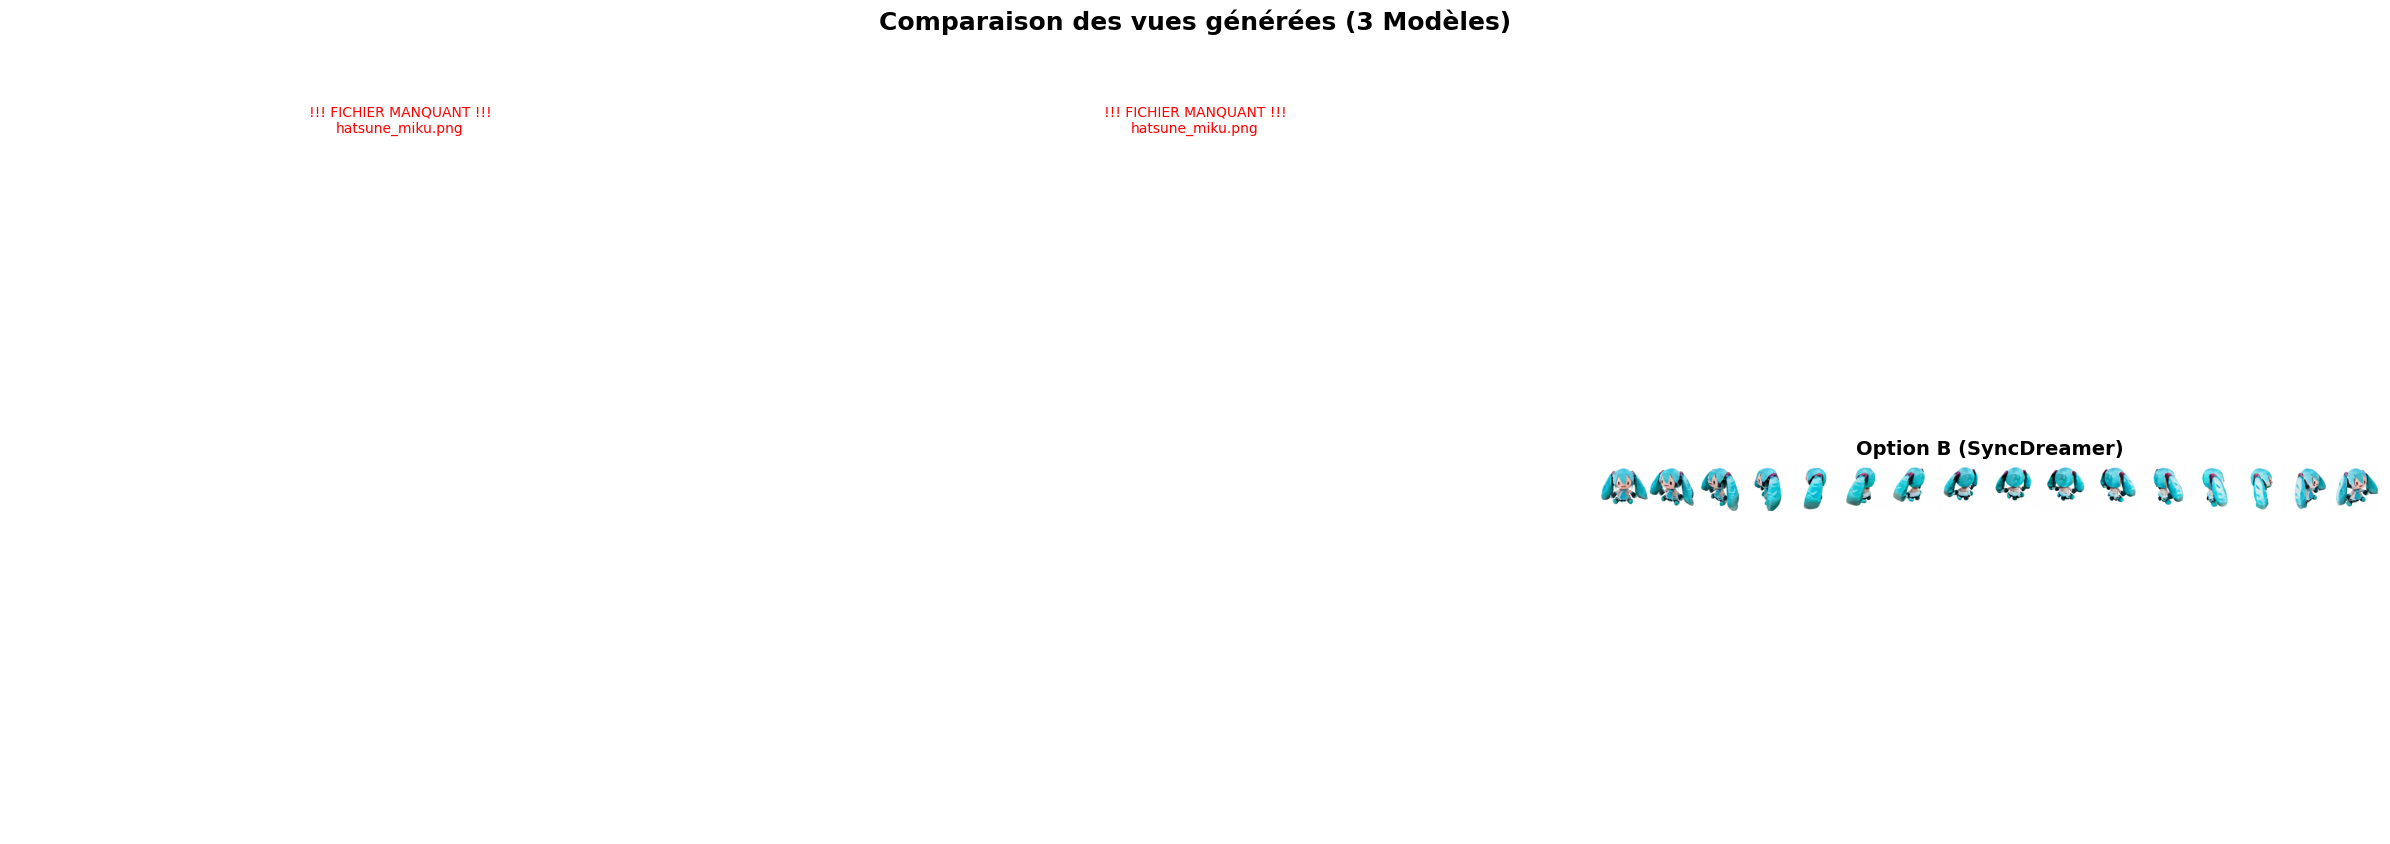


--- AFFICHAGE DES VIDÉOS ---
[X] Vidéo manquante pour Original (Fine-tuned) : outputs/instant-mesh-base_zero123plus_finetuned/videos/hatsune_miku.mp4
[X] Vidéo manquante pour Option A (Base) : outputs/instant-mesh-base_zero123plus_base/videos/hatsune_miku.mp4

[OK] Modèle : Option B (SyncDreamer)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Video
import os

# --- Vues multi-vues (Images) ---
# Note : Vérifie bien que les noms des dossiers correspondent à ceux créés lors de l'inférence
paths = {
    "Original (fine-tuned)": "outputs/instant-mesh-base_zero123plus_finetuned/images/hatsune_miku.png",
    "Option A (Zero123+ Base)": "outputs/instant-mesh-base_zero123plus_base/images/hatsune_miku.png",
    "Option B (SyncDreamer)": "/content/InstantMesh/outputs/instant-mesh-base_syncdreamer/images/hatsune_miku_syncdreamer_grid.png",
}

# On passe à 1 ligne et 3 colonnes, et on augmente la largeur (figsize)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, (label, path) in zip(axes, paths.items()):
    if os.path.exists(path):
        ax.imshow(np.array(Image.open(path)))
        ax.set_title(label, fontsize=14, fontweight='bold')
    else:
        ax.set_title(f"!!! FICHIER MANQUANT !!!\n{os.path.basename(path)}", color='red', fontsize=10)
        print(f"Attention : Image absente -> {path}")
    ax.axis('off')

plt.suptitle("Comparaison des vues générées (3 Modèles)", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

# Sauvegarde du comparatif
os.makedirs('outputs/comparaisons', exist_ok=True)
plt.savefig('outputs/comparaisons/comparaison_3_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Vidéos 3D ---
video_paths = {
    "Original (Fine-tuned)": "outputs/instant-mesh-base_zero123plus_finetuned/videos/hatsune_miku.mp4",
    "Option A (Base)": "outputs/instant-mesh-base_zero123plus_base/videos/hatsune_miku.mp4",
    "Option B (SyncDreamer)": "outputs/instant-mesh-base_syncdreamer/videos/hatsune_miku.mp4",
}

print("\n--- AFFICHAGE DES VIDÉOS ---")
for label, path in video_paths.items():
    if os.path.exists(path):
        print(f"\n[OK] Modèle : {label}")
        display(Video(path, embed=True, width=512))
    else:
        print(f"[X] Vidéo manquante pour {label} : {path}")

In [ ]:
!pip install lpips scikit-image "numpy==1.26.4" "scipy<1.13.0"

In [ ]:
import torch
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import lpips
import pandas as pd
import os
%cd /content/InstantMesh

# Initialisation du modèle LPIPS
loss_fn = lpips.LPIPS(net='alex')

def load_6views(path):
    img = np.array(Image.open(path).convert('RGB'), dtype=np.float32) / 255.0
    H, W = img.shape[0] // 3, img.shape[1] // 2
    views = []
    for row in range(3):
        for col in range(2):
            views.append(img[row*H:(row+1)*H, col*W:(col+1)*W])
    return np.stack(views)

def compute_metrics(path_ref, path_other):
    if not os.path.exists(path_ref) or not os.path.exists(path_other):
        return {'PSNR ↑': 'Erreur', 'SSIM ↑': 'Erreur', 'LPIPS ↓': f'Fichier manquant'}

    v_ref, v_other = load_6views(path_ref), load_6views(path_other)
    psnr_l, ssim_l, lpips_l = [], [], []
    for i in range(6):
        psnr_l.append(psnr(v_ref[i], v_other[i], data_range=1.0))
        ssim_l.append(ssim(v_ref[i], v_other[i], channel_axis=2, data_range=1.0))

        t1 = torch.from_numpy(v_ref[i]).permute(2,0,1).unsqueeze(0) * 2 - 1
        t2 = torch.from_numpy(v_other[i]).permute(2,0,1).unsqueeze(0) * 2 - 1
        lpips_l.append(loss_fn(t1, t2).item())

    return {'PSNR ↑': round(np.mean(psnr_l),3),
            'SSIM ↑': round(np.mean(ssim_l),4),
            'LPIPS ↓': round(np.mean(lpips_l),4)}

NOM_IMAGE = "hatsune_miku.png"

# Utilisation des CHEMINS ABSOLUS pour éviter que Colab se perde
path_ref  = f"/content/InstantMesh/outputs/instant-mesh-base_zero123plus_finetuned/images/{NOM_IMAGE}"
path_base = f"/content/InstantMesh/outputs/instant-mesh-base_zero123plus_base/images/{NOM_IMAGE}"

print("Calcul des métriques en cours...")
df = pd.DataFrame([
    {"Modèle": "Original fine-tuned (référence)", **compute_metrics(path_ref, path_ref)},
    {"Modèle": "Option A — base sans fine-tuning", **compute_metrics(path_ref, path_base)},
]).set_index("Modèle")

print("\n", df.to_string())

os.makedirs('/content/InstantMesh/outputs/comparaisons', exist_ok=True)
df.to_csv('/content/InstantMesh/outputs/comparaisons/metriques.csv')
print("\n Sauvegardé dans outputs/comparaisons/metriques.csv")